In [16]:
print("Hello")  

Hello


In [17]:
from schemas import QuestionPaperBlueprint, Section, QuestionSpec, QuestionType, SubPart, Slot, SlotSubPart, GenerationMode

In [18]:
question_paper = QuestionPaperBlueprint(
    school_name='SADHU VASWANI INTERNATIONAL SCHOOL',
    exam_title='PRE-MID TERM EXAMINATION: 2026-2027',
    subject='MATHEMATICS',
    grade=10,
    total_marks=40,
    duration_minutes=120,
    general_instructions=[
        'This question paper contains 19 questions. All questions are compulsory.',
        'This question paper is divided into five Sections -- A, B, C, D and E.',
        'In Section A, Question no. 1 to 8 are multiple choice questions (MCQs) and Question no. 9 and 10 are Assertion-Reason based questions of 1 mark each.',
        'In Section B, Question no. 11 and 12 are very short answer (VSA) type questions, carrying 2 marks each.',
        'In Section C, Question no. 13 to 15 are short answer (SA) type questions, carrying 3 marks each.',
        'In Section D, Question no. 16 and 17 are long answer (LA) type questions, carrying 5 marks each.',
        'Section E, Question no. 18 and 19 are Case Study based questions carrying 4 marks and 3 marks each.',
        'There is no overall choice. However an internal choice is provided in 1 Question in Section B, 1 Question in Section C, 1 Question in Section D and 1 Question in Section E.',
        'Draw neat diagrams wherever required.',
        'Use of calculator is not allowed.',
    ],
    sections=[
        Section(
            section_name='Section A',
            section_instructions='This section comprises Multiple Choice Questions (MCQs) of 1 mark each. 10X1=10M',
            questions=[
                QuestionSpec(question_number=i, question_type=QuestionType.MCQ, marks=1.0, has_internal_choice=False, sub_parts=[])
                for i in range(1, 9)
            ] + [
                QuestionSpec(question_number=9, question_type=QuestionType.ASSERTION_REASON, marks=1.0, has_internal_choice=False, sub_parts=[]),
                QuestionSpec(question_number=10, question_type=QuestionType.ASSERTION_REASON, marks=1.0, has_internal_choice=False, sub_parts=[]),
            ],
            stated_total_marks=10.0,
        ),
        Section(
            section_name='Section B',
            section_instructions='This section comprises Very Short Answer (VSA) type questions of 2 marks each. 2X2=4M',
            questions=[
                QuestionSpec(
                    question_number=11, question_type=QuestionType.VSA, marks=2.0, has_internal_choice=True,
                    sub_parts=[SubPart(label='a', marks=2.0, has_internal_choice=False), SubPart(label='b', marks=2.0, has_internal_choice=False)],
                ),
                QuestionSpec(question_number=12, question_type=QuestionType.VSA, marks=2.0, has_internal_choice=False, sub_parts=[]),
            ],
            stated_total_marks=4.0,
        ),
        Section(
            section_name='Section C',
            section_instructions='This section comprises Short Answer (SA) type questions of 3 marks each. 3X3 = 9M',
            questions=[
                QuestionSpec(question_number=13, question_type=QuestionType.SA, marks=3.0, has_internal_choice=False, sub_parts=[]),
                QuestionSpec(
                    question_number=14, question_type=QuestionType.SA, marks=3.0, has_internal_choice=True,
                    sub_parts=[SubPart(label='a', marks=3.0, has_internal_choice=False), SubPart(label='b', marks=3.0, has_internal_choice=False)],
                ),
                QuestionSpec(question_number=15, question_type=QuestionType.SA, marks=3.0, has_internal_choice=False, sub_parts=[]),
            ],
            stated_total_marks=9.0,
        ),
        Section(
            section_name='Section D',
            section_instructions='This section comprises Long Answer (LA) type questions of 5 marks each. 2X5 = 10M',
            questions=[
                QuestionSpec(question_number=16, question_type=QuestionType.LA, marks=5.0, has_internal_choice=False, sub_parts=[]),
                QuestionSpec(
                    question_number=17, question_type=QuestionType.LA, marks=5.0, has_internal_choice=True,
                    sub_parts=[SubPart(label='Option 1', marks=5.0, has_internal_choice=False), SubPart(label='Option 2', marks=5.0, has_internal_choice=False)],
                ),
            ],
            stated_total_marks=10.0,
        ),
        Section(
            section_name='Section E',
            section_instructions='This section comprises 2 case study based questions of 4 and 3 marks each.',
            questions=[
                QuestionSpec(
                    question_number=18, question_type=QuestionType.CASE_STUDY, marks=4.0, has_internal_choice=True,
                    sub_parts=[
                        SubPart(label='i', marks=1.0, has_internal_choice=False),
                        SubPart(label='ii', marks=1.0, has_internal_choice=False),
                        SubPart(label='iii (a)', marks=2.0, has_internal_choice=False),
                        SubPart(label='b', marks=2.0, has_internal_choice=False),
                    ],
                ),
                QuestionSpec(
                    question_number=19, question_type=QuestionType.CASE_STUDY, marks=3.0, has_internal_choice=False,
                    sub_parts=[
                        SubPart(label='i', marks=1.0, has_internal_choice=False),
                        SubPart(label='ii', marks=1.0, has_internal_choice=False),
                        SubPart(label='iii', marks=1.0, has_internal_choice=False),
                    ],
                ),
            ],
            stated_total_marks=7.0,
        ),
    ],
)

In [19]:
selected_chapters = [1, 2]
chapter_names = {
    1: "Real Numbers",
    3: "Polynomials"
}
paper_id = "001"

In [20]:
initial_state = {
    "question_paper": question_paper.model_dump(mode="json"),
    "selected_chapters": [1,2],
    "chapter_names": {"1": "Real Numbers"},
    "subject": question_paper.subject,
    "grade": question_paper.grade,
    "paper_id": paper_id,
    "slots": [],
    "generated_items": [],
    "final_paper": None,
    "final_answer_key": None,
    "review_decision": None,
}

## NODE 1

In [21]:
from schemas import BloomsLevel, GenerationState
from collections import defaultdict

BLOOMS_DEFAULTS: dict[QuestionType, list[BloomsLevel]] = {
    QuestionType.MCQ: [BloomsLevel.REMEMBERING, BloomsLevel.UNDERSTANDING],
    QuestionType.ASSERTION_REASON: [BloomsLevel.UNDERSTANDING, BloomsLevel.ANALYSING],
    QuestionType.VSA: [BloomsLevel.UNDERSTANDING],
    QuestionType.SA: [BloomsLevel.APPLYING],
    QuestionType.LA: [BloomsLevel.APPLYING, BloomsLevel.EVALUATING],
    QuestionType.CASE_STUDY: [BloomsLevel.ANALYSING, BloomsLevel.CREATING],
}


def decide_blooms_level(question_type: QuestionType, index_within_type: int) -> BloomsLevel:
    options = BLOOMS_DEFAULTS.get(question_type, [BloomsLevel.NOT_SPECIFIED])
    return options[index_within_type % len(options)]


def assign_chapters(n: int, chapter_weights: dict[int, float]) -> list[int]:
    """Largest-remainder apportionment of n questions across the selected chapters by
    weight (equal weight for all selected chapters unless the caller overrides), then
    interleaved so consecutive questions aren't all from the same chapter."""
    if n == 0 or not chapter_weights:
        return []
    total_weight = sum(chapter_weights.values())
    normalized = {ch: w / total_weight for ch, w in chapter_weights.items()}
    raw = {ch: normalized[ch] * n for ch in normalized}
    counts = {ch: int(raw[ch]) for ch in raw}
    remainder_n = n - sum(counts.values())
    by_remainder = sorted(raw.items(), key=lambda kv: kv[1] - counts[kv[0]], reverse=True)
    for ch, _ in by_remainder[:remainder_n]:
        counts[ch] += 1

    pool, remaining = [], dict(counts)
    cycle = list(remaining.keys())
    while sum(remaining.values()) > 0:
        for ch in cycle:
            if remaining[ch] > 0:
                pool.append(ch)
                remaining[ch] -= 1
    return pool[:n]

def decide_generation_mode(question_type: QuestionType, marks: float) -> GenerationMode:
    if question_type == QuestionType.MCQ:
        return GenerationMode.REUSE
    if question_type == QuestionType.VSA and marks <= 2:
        return GenerationMode.REUSE
    if question_type == QuestionType.SA:
        return GenerationMode.VARIANT
    if question_type in (QuestionType.LA, QuestionType.CASE_STUDY, QuestionType.ASSERTION_REASON):
        # Assertion-Reason isn't a reworded textbook exercise - it's a fresh true/false-style
        # claim grounded in the chapter's theory, so it belongs with the "novel" modes.
        return GenerationMode.NOVEL
    return GenerationMode.VARIANT
    
def build_slots(
    question_paper: QuestionPaperBlueprint,
    selected_chapters: list[int],
    chapter_weights: dict[int, float] | None = None,
    chapter_names: dict[int, str] | None = None,
) -> list[Slot]:
    if not selected_chapters:
        raise ValueError("selected_chapters is empty - pick at least one chapter before generating")

    weights = chapter_weights or {ch: 1.0 for ch in selected_chapters}
    # keep only weights for chapters actually selected; default any missing ones to equal share
    weights = {ch: weights.get(ch, 1.0) for ch in selected_chapters}
    chapter_names = chapter_names or {}

    all_questions = [(section, q) for section in question_paper.sections for q in section.questions]
    chapter_pool = iter(assign_chapters(len(all_questions), weights))

    type_counters: dict[QuestionType, int] = defaultdict(int)
    slots = []
    for section, q in all_questions:
        idx = type_counters[q.question_type]
        type_counters[q.question_type] += 1
        chapter_number = next(chapter_pool)

        slots.append(Slot(
            slot_id=f"Q{q.question_number}",
            section_name=section.section_name,
            question_number=q.question_number,
            question_type=q.question_type,
            marks=q.marks,
            blooms_level=decide_blooms_level(q.question_type, idx),
            chapter_number=chapter_number,
            chapter_name=chapter_names.get(chapter_number, f"Chapter {chapter_number}"),
            generation_mode=decide_generation_mode(q.question_type, q.marks),
            has_internal_choice=q.has_internal_choice,
            sub_parts=[SlotSubPart(label=sp.label, marks=sp.marks, has_internal_choice=sp.has_internal_choice)
                       for sp in q.sub_parts],
        ))
    return slots


def plan_slots_node(state: GenerationState) -> dict:
    question_paper = QuestionPaperBlueprint.model_validate(state["question_paper"])
    slots = build_slots(
        question_paper, state["selected_chapters"],
        state.get("chapter_weights"), state.get("chapter_names"),
    )
    return {"slots": [s.model_dump(mode="json") for s in slots]}


## Final Graph

In [22]:
from langgraph.graph.state import END, START, StateGraph


builder = StateGraph(GenerationState)
builder.add_node("plan_slots", plan_slots_node)

builder.add_edge(START, "plan_slots")
builder.add_edge("plan_slots", END)

graph = builder.compile()


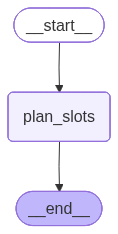

In [23]:
graph

In [24]:
result = graph.invoke(initial_state)


In [25]:
result

{'question_paper': {'school_name': 'SADHU VASWANI INTERNATIONAL SCHOOL',
  'exam_title': 'PRE-MID TERM EXAMINATION: 2026-2027',
  'subject': 'MATHEMATICS',
  'grade': 10,
  'total_marks': 40,
  'duration_minutes': 120,
  'general_instructions': ['This question paper contains 19 questions. All questions are compulsory.',
   'This question paper is divided into five Sections -- A, B, C, D and E.',
   'In Section A, Question no. 1 to 8 are multiple choice questions (MCQs) and Question no. 9 and 10 are Assertion-Reason based questions of 1 mark each.',
   'In Section B, Question no. 11 and 12 are very short answer (VSA) type questions, carrying 2 marks each.',
   'In Section C, Question no. 13 to 15 are short answer (SA) type questions, carrying 3 marks each.',
   'In Section D, Question no. 16 and 17 are long answer (LA) type questions, carrying 5 marks each.',
   'Section E, Question no. 18 and 19 are Case Study based questions carrying 4 marks and 3 marks each.',
   'There is no overall